In [45]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [46]:
%connect_info

{"key":"798caaee-6b32-428a-807c-2b475f53a834","signature_scheme":"hmac-sha256","transport":"tcp","ip":"127.0.0.1","hb_port":9008,"control_port":9009,"shell_port":9010,"stdin_port":9011,"iopub_port":9012,"kernel_name":"python31313jvsc74a57bd02bbbccf2108b707be89a1a9785f12d724b6e84686269abbefa54627529b64920"}

Paste the above JSON into a file, and connect with:
    $> jupyter <app> --existing <file>
or, if you are local, you can connect with just:
    $> jupyter <app> --existing /run/user/1000/jupyter/runtime/kernel-v3dfea07b6b5fc035282468f7770cad2e213c2f180.json
or even just:
    $> jupyter <app> --existing
if this is the most recent Jupyter kernel you have started.


In [47]:
#Import the date from Full_Dataset.csv

df_all = pd.read_csv('Full_Dataset.csv', header=0)
df_all.rename(columns={'Date': 'time'}, inplace=True)
df_all['time'] = pd.to_datetime(df_all['time'], dayfirst=True)
df_all.set_index('time', inplace=True)

df_all = df_all.groupby(level=0).mean()
data = df_all[['Price_BE', 'Solar_BE', 'Wind_BE', 'Load_BE']].resample('1h').mean().ffill()
data.columns = ['belpex', 'solar', 'wind', 'load']
# data contains: belpex, solar, wind, load

# Define lookback window
lookback = 7   # use past 7 days to predict next day

# Build 3D input array
features = ['belpex', 'solar', 'wind', 'load']
n_features = len(features)

X_lstm, Y_lstm = [], []

# Scale raw data first
scaler_lstm_x = StandardScaler()
scaler_lstm_y = StandardScaler()

data_scaled = data.copy()
data_scaled[features] = scaler_lstm_x.fit_transform(data[features])
price_scaled = scaler_lstm_y.fit_transform(
    data['belpex'].values.reshape(-1, 1)
)

days = len(data) // 24

for d in range(lookback, days):
    # Past 7 days of all features (hourly)
    past = data_scaled[features].values[(d-lookback)*24 : d*24]
    # Shape: (lookback×24, n_features) = (168, 4)
    
    # Next 24 hours of prices
    future = price_scaled[d*24 : (d+1)*24]
    # Shape: (24, 1)
    
    X_lstm.append(past)
    Y_lstm.append(future.flatten())

X_lstm = np.array(X_lstm)   # shape: (n_days, 168, 4)
Y_lstm = np.array(Y_lstm)   # shape: (n_days, 24)

print(f"X shape: {X_lstm.shape}")
print(f"Y shape: {Y_lstm.shape}")

X shape: (1874, 168, 4)
Y shape: (1874, 24)


In [48]:
from sklearn.model_selection import train_test_split

# Same 70/15/15 split as your ANN
X_tv, X_test, Y_tv, Y_test = train_test_split(
    X_lstm, Y_lstm, test_size=0.15, shuffle=False
)
X_train, X_val, Y_train, Y_val = train_test_split(
    X_tv, Y_tv, test_size=0.176, shuffle=False
)

print(f"Train: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")

Train: (1311, 168, 4)
Val:   (281, 168, 4)
Test:  (282, 168, 4)


In [49]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Bidirectional, Attention, Concatenate

# Example of an improved architecture
model_lstm = Sequential([
    Bidirectional(LSTM(128, return_sequences=True), input_shape=(168, 5)), # Added 1 extra temporal feature
    Dropout(0.3),
    LSTM(64, return_sequences=False),
    Dense(64, activation='relu'),
    Dense(24, activation='linear')
])

model_lstm.compile(loss='mse', optimizer='adam') # Switched to MSE to better capture spikes

# model_lstm.compile(
#     loss='mae',
#     optimizer=Adam(learning_rate=0.001),
#     metrics=['mae']
# )

model_lstm.summary()

/home/geile_kerk/Documents/SEMESTER 2/SmartDistributionSystems/SDS-Assignment/sds_env/lib/python3.13/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 168, 256)       │       137,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 168, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 64)             │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,112 (879.34 KB)

 Trainable params: 225,112 (879.34 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Training using Callbacks (Not sure how does it work yet)
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=0.00001,
        verbose=1
    )
]

history_lstm = model_lstm.fit(
    X_train, Y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, Y_val),
    callbacks=callbacks,
    verbose=1
)

NameError: name 'model_ltsm' is not defined

In [8]:
#Update the parameters and keep training
model_lstm.compile(
    loss='mae',
    optimizer=Adam(learning_rate=0.000001),
    metrics=['mae']
)

history_lstm = model_lstm.fit(
    X_train, Y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, Y_val),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.2404 - mae: 0.2404 - val_loss: 0.2105 - val_mae: 0.2105 - learning_rate: 1.0000e-06
Epoch 2/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.2388 - mae: 0.2388 - val_loss: 0.2105 - val_mae: 0.2105 - learning_rate: 1.0000e-06
Epoch 3/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.2372 - mae: 0.2372 - val_loss: 0.2106 - val_mae: 0.2106 - learning_rate: 1.0000e-06
Epoch 4/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.2382 - mae: 0.2382 - val_loss: 0.2106 - val_mae: 0.2106 - learning_rate: 1.0000e-06
Epoch 5/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.2395 - mae: 0.2395 - val_loss: 0.2107 - val_mae: 0.2107 - learning_rate: 1.0000e-06
Epoch 6/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.2376 - mae: 0.2376 - val_loss: 0.2107 - val_mae: 0.2107 - learning_rate: 1.0000e-06
Epoch 7/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.2416 - mae: 0.2416 - val_loss: 0.2107 - val_mae: 0.2107 - lear

In [9]:
# Generate predictions
pred_scaled = model_lstm.predict(X_test)

# Inverse transform
pred_real = scaler_lstm_y.inverse_transform(pred_scaled)
actual_real = scaler_lstm_y.inverse_transform(Y_test)

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae  = mean_absolute_error(actual_real, pred_real)
rmse = np.sqrt(mean_squared_error(actual_real, pred_real))
mask = actual_real != 0
mape = np.mean(np.abs(
    (actual_real[mask] - pred_real[mask]) / actual_real[mask]
)) * 100

smape = np.mean(2 * np.abs(actual_real - pred_real) / (np.abs(actual_real) + np.abs(pred_real))) * 100
print("\n--- LSTM Performance ---")
print(f"MAE:  {mae:.2f}  €/MWh")
print(f"RMSE: {rmse:.2f} €/MWh")
print(f"MAPE yeah this is wrong: {mape:.2f}%")
print(f"sMAPE: {smape:.2f}%")

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step

--- LSTM Performance ---
MAE:  17.77  €/MWh
RMSE: 25.53 €/MWh
MAPE yeah this is wrong: 1668574181923697.00%
sMAPE: 35.04%


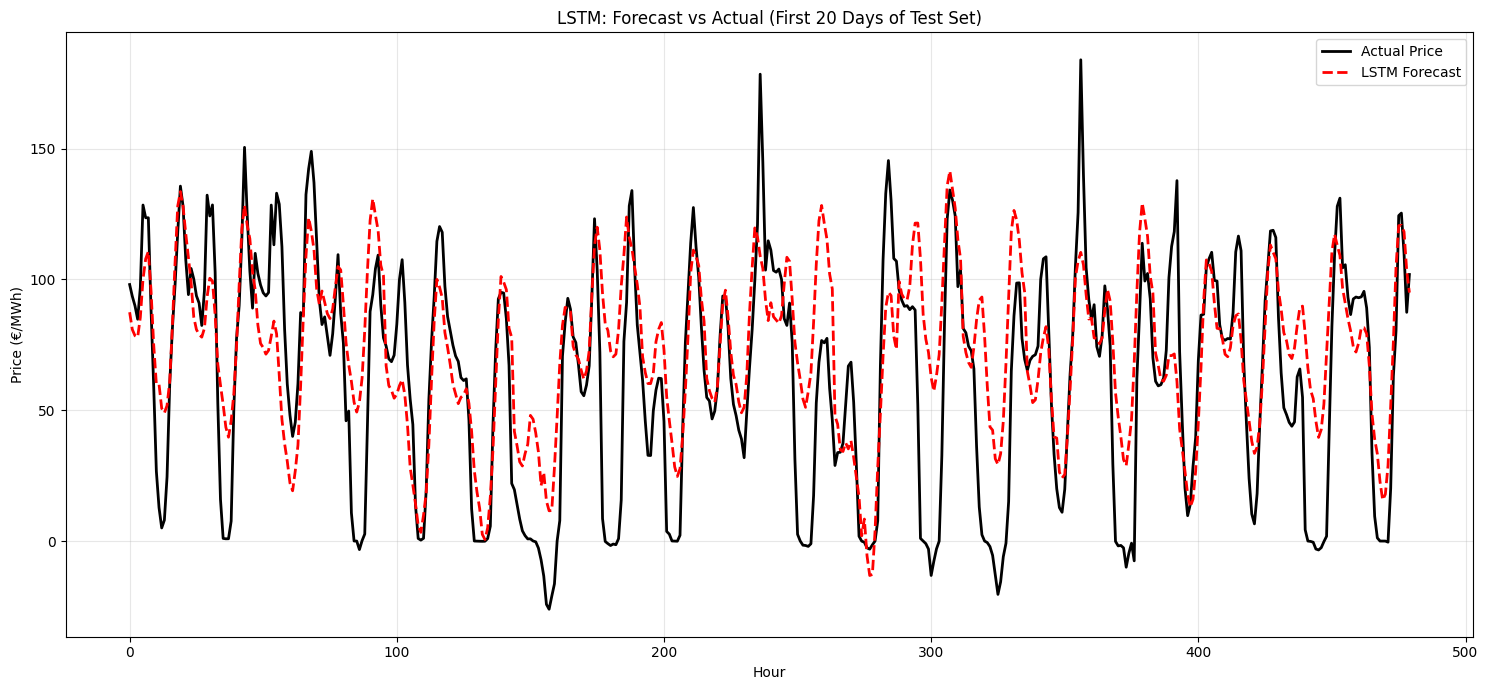

In [10]:
import matplotlib.pyplot as plt

n_plot = 72  # first 3 days

plt.figure(figsize=(15, 7))
plt.plot(actual_real[:20].flatten(),
         label='Actual Price',
         color='black', linewidth=2)
plt.plot(pred_real[:20].flatten(),
         label='LSTM Forecast',
         color='red', linestyle='--', linewidth=2)

plt.title('LSTM: Forecast vs Actual (First 20 Days of Test Set)')
plt.xlabel('Hour')
plt.ylabel('Price (€/MWh)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
import os
import pickle

# 1. Create the directory if it doesn't exist
save_dir = "./trained_model"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
    print(f"Created directory: {save_dir}")

# 2. Save the model
model_path = os.path.join(save_dir, "LSTM_model_1.keras") # Corrected LTSM to LSTM
model_lstm.save(model_path)
print(f"Model saved successfully to: {model_path}")

# 3. Save the scalers
scaler_x_path = os.path.join(save_dir, "LSTM_scaler_x.pkl")
with open(scaler_x_path, 'wb') as f:
    pickle.dump(scaler_lstm_x, f)
print(f"X Scaler saved successfully to: {scaler_x_path}")

scaler_y_path = os.path.join(save_dir, "LSTM_scaler_y.pkl")
with open(scaler_y_path, 'wb') as f:
    pickle.dump(scaler_lstm_y, f)
print(f"Y Scaler saved successfully to: {scaler_y_path}")

Model saved successfully to: ./trained_model/LSTM_model_1.keras
X Scaler saved successfully to: ./trained_model/LSTM_scaler_x.pkl
Y Scaler saved successfully to: ./trained_model/LSTM_scaler_y.pkl


/home/geile_kerk/Documents/SEMESTER 2/SmartDistributionSystems/SDS-Assignment/sds_env/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



--- Model Performance Comparison (Last 72 Hours) ---
               Model  MSE [€/MWh]^2  MAE [€/MWh]
        Naive Weekly         361.35        13.77
7-Day Hourly Average         395.15        16.73
 LSTM Neural Network         308.81        12.49


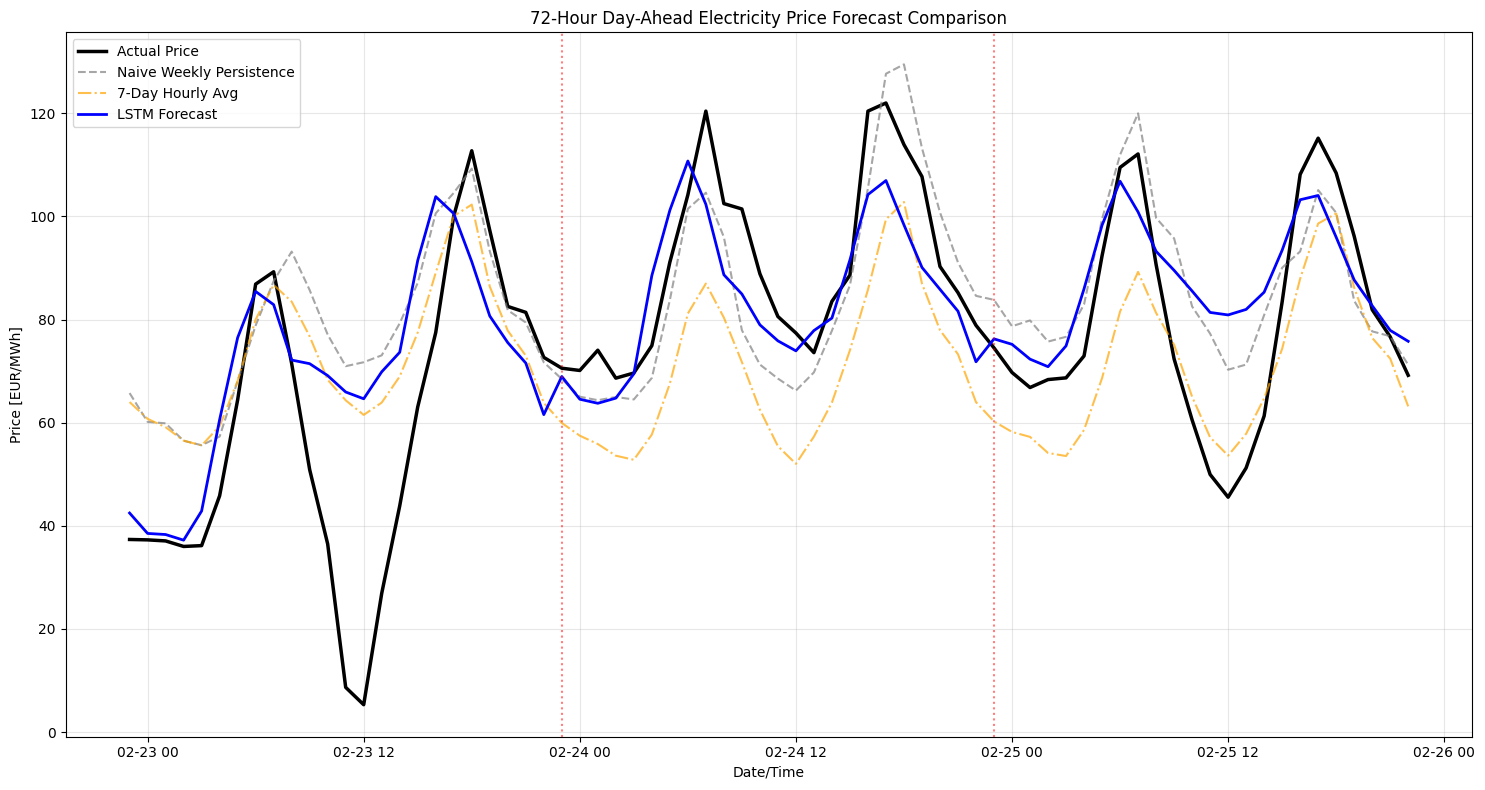

In [21]:
import pandas as pd
import numpy as np
import pickle
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# --- 1. Load the Data ---
df_hourly = pd.read_csv('Full_Dataset.csv')
df_hourly['Date'] = pd.to_datetime(df_hourly['Date'], dayfirst=True)
df_hourly = df_hourly.set_index('Date').sort_index()

# Select the features used during training
features = ['Price_BE', 'Solar_BE', 'Wind_BE', 'Load_BE']
df_features = df_hourly[features].copy()

# The assignment asks for the last 72 hours (3 days) of the test set[cite: 1]
# Based on your lookback window (7 days = 168 hours) and forecasting horizon (24 hours), 
# we need the preceding 168 hours of data to make predictions for any given 24-hour block.
# Let's extract the actuals for the very last 72 hours of the dataset.
test_actuals = df_hourly['Price_BE'].tail(72)

# --- 2. Calculate Baselines for the last 72 hours ---
results_df = pd.DataFrame(index=test_actuals.index)
results_df['Actual'] = test_actuals.values

naive_weekly = []
avg_hourly_week = []

for timestamp in test_actuals.index:
    t_minus_7 = timestamp - pd.Timedelta(days=7)
    naive_weekly.append(df_hourly.loc[t_minus_7, 'Price_BE'] if t_minus_7 in df_hourly.index else np.nan)
    
    past_7_days_prices = []
    for d in range(1, 8):
        t_prev = timestamp - pd.Timedelta(days=d)
        if t_prev in df_hourly.index:
            past_7_days_prices.append(df_hourly.loc[t_prev, 'Price_BE'])
    avg_hourly_week.append(np.mean(past_7_days_prices) if past_7_days_prices else np.nan)

results_df['Naive_Weekly'] = naive_weekly
results_df['Avg_Hour_Last_Week'] = avg_hourly_week


# --- 3. Generate LSTM Predictions for the last 72 hours ---
try:
    model_lstm = load_model('./trained_model/LSTM_model_1.keras')
    with open('./trained_model/LSTM_scaler_x.pkl', 'rb') as f:
        scaler_x = pickle.load(f)
    with open('./trained_model/LSTM_scaler_y.pkl', 'rb') as f:
        scaler_y = pickle.load(f)
except Exception as e:
    print(f"Error loading model/scalers: {e}")
    results_df['LSTM_Predict'] = np.nan 

if 'LSTM_Predict' not in results_df.columns:
    # 1. Define the columns in the EXACT order used during training
    # Training Order: belpex (Price), solar, wind, load
    raw_feature_cols = ['Price_BE', 'Solar_BE', 'Wind_BE', 'Load_BE']
    
    # 2. Extract only these columns
    df_for_scaling = df_hourly[raw_feature_cols].copy()
    
    # 3. Use .values to convert to a NumPy array before transforming.
    # This bypasses scikit-learn's feature name validation.
    scaled_values = scaler_x.transform(df_for_scaling.values)
    
    # Reconstruct the scaled DataFrame for easier indexing
    df_scaled = pd.DataFrame(scaled_values, index=df_for_scaling.index, columns=raw_feature_cols)
    
    start_times = [
        test_actuals.index[0],   # Start of Day -3
        test_actuals.index[24],  # Start of Day -2
        test_actuals.index[48]   # Start of Day -1
    ]
    
    all_predictions = []
    
    for start_time in start_times:
        input_end = start_time - pd.Timedelta(hours=1)
        input_start = start_time - pd.Timedelta(hours=168)
        
        input_seq = df_scaled.loc[input_start:input_end].values
        
        if len(input_seq) == 168:
            # Reshape for LSTM: (1 sample, 168 timesteps, 4 features)
            input_seq = input_seq.reshape(1, 168, 4)
            pred_scaled = model_lstm.predict(input_seq, verbose=0)
            
            # Inverse transform the 24-hour prediction
            pred_real = scaler_y.inverse_transform(pred_scaled)
            all_predictions.extend(pred_real[0])
        else:
            print(f"Warning: Insufficient historical data for {start_time}")
            all_predictions.extend([np.nan] * 24)
            
    results_df['LSTM_Predict'] = all_predictions

# --- 4. Calculate and Display Metrics ---
def calculate_metrics(actual, predicted, model_name):
    # Filter out NaNs if any exist to prevent calculation errors
    mask = ~np.isnan(predicted) & ~np.isnan(actual)
    if not mask.any():
         return {'Model': model_name, 'MSE': np.nan, 'MAE': np.nan}
    
    mse = mean_squared_error(actual[mask], predicted[mask])
    mae = mean_absolute_error(actual[mask], predicted[mask])
    return {'Model': model_name, 'MSE [€/MWh]^2': round(mse, 2), 'MAE [€/MWh]': round(mae, 2)}

metrics_summary = [
    calculate_metrics(results_df['Actual'], results_df['Naive_Weekly'], 'Naive Weekly'),
    calculate_metrics(results_df['Actual'], results_df['Avg_Hour_Last_Week'], '7-Day Hourly Average'),
    calculate_metrics(results_df['Actual'], results_df['LSTM_Predict'], 'LSTM Neural Network')
]

metrics_df = pd.DataFrame(metrics_summary)
print("\n--- Model Performance Comparison (Last 72 Hours) ---")
print(metrics_df.to_string(index=False))


# --- 5. Plotting ---
plt.figure(figsize=(15, 8))

# Plot Actuals
plt.plot(results_df.index, results_df['Actual'], label='Actual Price', color='black', linewidth=2.5)

# Plot Baselines
plt.plot(results_df.index, results_df['Naive_Weekly'], label='Naive Weekly Persistence', color='gray', linestyle='--', alpha=0.7)
plt.plot(results_df.index, results_df['Avg_Hour_Last_Week'], label='7-Day Hourly Avg', color='orange', linestyle='-.', alpha=0.7)

# Plot LSTM
if not results_df['LSTM_Predict'].isna().all():
    plt.plot(results_df.index, results_df['LSTM_Predict'], label='LSTM Forecast', color='blue', linewidth=2)

plt.title('72-Hour Day-Ahead Electricity Price Forecast Comparison')
plt.xlabel('Date/Time')
plt.ylabel('Price [EUR/MWh]')

# Add vertical lines to separate the 3 forecasted days
for i in range(24, 72, 24):
    plt.axvline(x=results_df.index[i], color='red', linestyle=':', alpha=0.5)

plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
#Reload the model
from tensorflow.keras.models import load_model

model_lstm_loaded = load_model('./trained_model/LSTM_model_1.keras')

#Load the scalers
with open('./trained_model/LSTM_scaler_x.pkl', 'rb') as f:
    scaler_lstm_x = pickle.load(f)

with open('./trained_model/LSTM_scaler_y.pkl', 'rb') as f:
    scaler_lstm_y = pickle.load(f)

# Verify
model_lstm_loaded.summary()

# Predict immediately
# X_test from the training notebook is already scaled[cite: 1]
pred_scaled = model_lstm_loaded.predict(X_test)

# Use the correctly loaded variable name: scaler_lstm_y
pred_real = scaler_lstm_y.inverse_transform(pred_scaled)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 168, 64)        │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 168, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │           792 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,618 (361.79 KB)

 Trainable params: 30,872 (120.59 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 61,746 (241.20 KB)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


The model is able to smooth out the average patterns but it fails to accurately capture the troughs. Next thing we want to try is to split this into 3 zones, peak, normal, low for training.

In [27]:
import numpy as np
import pandas as pd

# ── Use actual (unscaled) prices to define periods ──
actual_train_real = scaler_lstm_y.inverse_transform(Y_train)
actual_test_real  = scaler_lstm_y.inverse_transform(Y_test)

# Daily average price for each training day
daily_avg_price = actual_train_real.mean(axis=1)

# Define thresholds
low_threshold  = np.percentile(daily_avg_price, 33)  # bottom 33%
high_threshold = np.percentile(daily_avg_price, 67)  # top 33%

print(f"Low demand threshold:    < {low_threshold:.2f}  €/MWh")
print(f"Normal demand range:     {low_threshold:.2f} - {high_threshold:.2f} €/MWh")
print(f"High demand threshold:   > {high_threshold:.2f} €/MWh")

# Create masks
is_low_demand    = daily_avg_price < low_threshold
is_high_demand   = daily_avg_price > high_threshold
is_normal_demand = ~is_low_demand & ~is_high_demand

print(f"\nLow demand days:    {is_low_demand.sum()}")
print(f"Normal demand days: {is_normal_demand.sum()}")
print(f"High demand days:   {is_high_demand.sum()}")

Low demand threshold:    < 75.15  €/MWh
Normal demand range:     75.15 - 143.47 €/MWh
High demand threshold:   > 143.47 €/MWh

Low demand days:    433
Normal demand days: 445
High demand days:   433


High demand samples:   433
Low demand samples:    433
Normal demand samples: 445


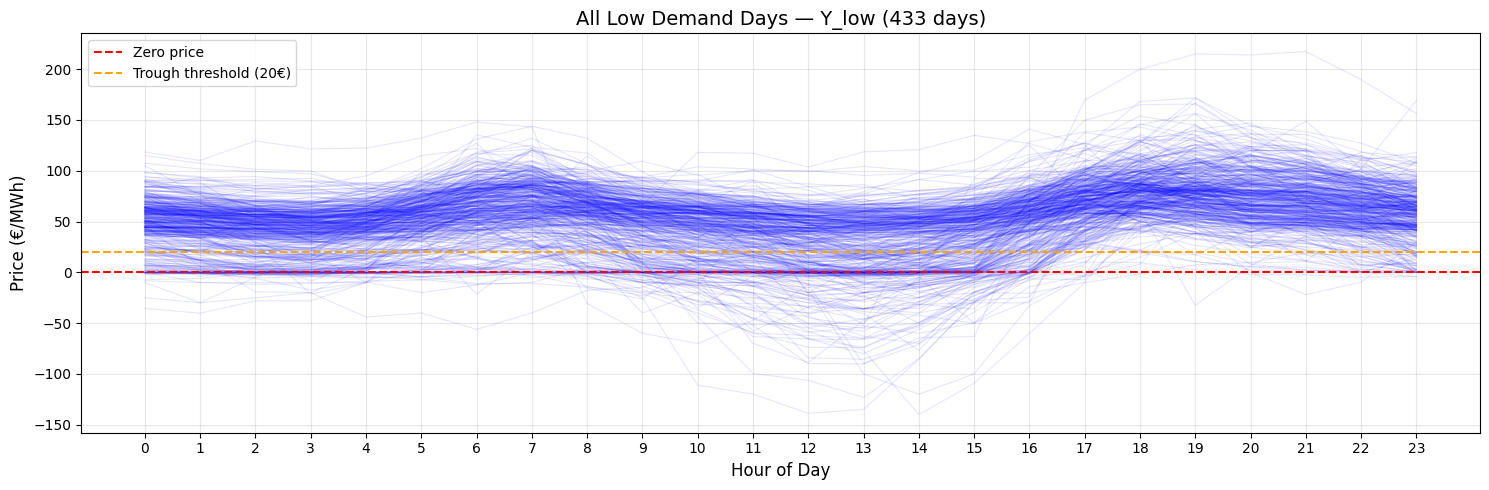

In [28]:
X_high = X_train[is_high_demand]
Y_high = Y_train[is_high_demand]

# ── Low demand ──
X_low  = X_train[is_low_demand]
Y_low  = Y_train[is_low_demand]

# ── Normal demand ──
X_normal = X_train[is_normal_demand]
Y_normal = Y_train[is_normal_demand]

print(f"High demand samples:   {len(X_high)}")
print(f"Low demand samples:    {len(X_low)}")
print(f"Normal demand samples: {len(X_normal)}")

import matplotlib.pyplot as plt
import numpy as np

# ── Inverse transform to real prices ──
actual_low_real = scaler_lstm_y.inverse_transform(Y_low)

# ── Plot all low demand days ──
plt.figure(figsize=(15, 5))
plt.plot(actual_low_real.T,          # transpose so each column = 1 day
         color='blue', alpha=0.1,    # transparent so overlaps visible
         linewidth=0.8)

plt.axhline(y=0,  color='red',    linestyle='--', 
            linewidth=1.5, label='Zero price')
plt.axhline(y=20, color='orange', linestyle='--', 
            linewidth=1.5, label='Trough threshold (20€)')

plt.title(f'All Low Demand Days — Y_low ({len(Y_low)} days)', fontsize=14)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Price (€/MWh)', fontsize=12)
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def build_lstm(input_shape, name):
    model = Sequential([
        LSTM(64, return_sequences=True,
             input_shape=input_shape),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(24, activation='linear')
    ], name=name)
    
    model.compile(
        loss=Huber(delta=1.0),
        optimizer=Adam(learning_rate=0.001),
        metrics=['mae']
    )
    return model

input_shape = (X_train.shape[1], X_train.shape[2])

model_high   = build_lstm(input_shape, 'lstm_high_demand')
model_low    = build_lstm(input_shape, 'lstm_low_demand')
model_normal = build_lstm(input_shape, 'lstm_normal_demand')

print("Three models built ✅")

Three models built ✅


/home/geile_kerk/Documents/SEMESTER 2/SmartDistributionSystems/SDS-Assignment/sds_env/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [30]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=0.00001, verbose=1)
]

print("Training HIGH demand model...")
history_high = model_high.fit(
    X_high, Y_high,
    epochs=100, batch_size=32,
    validation_data=(X_val, Y_val),
    callbacks=callbacks, verbose=1
)

print("\nTraining LOW demand model...")
history_low = model_low.fit(
    X_low, Y_low,
    epochs=100, batch_size=32,
    validation_data=(X_val, Y_val),
    callbacks=callbacks, verbose=1
)

print("\nTraining NORMAL demand model...")
history_normal = model_normal.fit(
    X_normal, Y_normal,
    epochs=100, batch_size=32,
    validation_data=(X_val, Y_val),
    callbacks=callbacks, verbose=1
)

Training HIGH demand model...
Epoch 1/100


14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.8308 - mae: 1.2381 - val_loss: 0.1692 - val_mae: 0.4658 - learning_rate: 0.0010
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.5910 - mae: 0.9533 - val_loss: 0.1908 - val_mae: 0.5212 - learning_rate: 0.0010
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.4477 - mae: 0.7805 - val_loss: 0.1575 - val_mae: 0.4414 - learning_rate: 0.0010
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.3517 - mae: 0.6667 - val_loss: 0.1577 - val_mae: 0.4420 - learning_rate: 0.0010
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.2947 - mae: 0.5969 - val_loss: 0.1570 - val_mae: 0.4415 - learning_rate: 0.0010
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.2593 - mae: 0.5496 - val_loss: 0.1530 - val_mae: 0.4331 - learning_rate: 0.0010
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.2491 - mae: 0.5403 - val_loss: 0.1572 - val_mae: 0.4447 - learning_rate: 0.0010
Epoch 8/100
14/14 

In [31]:
#Retraining the LOW demand model:
model_low.compile(
    loss='mae',
    optimizer=Adam(learning_rate=0.000001),
    metrics=['mae']
)

history_low = model_low.fit(
    X_low, Y_low,
    epochs=100, batch_size=4,
    validation_data=(X_val, Y_val),
    callbacks=callbacks, verbose=1
)

Epoch 1/100


109/109 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 0.2517 - mae: 0.2517 - val_loss: 0.3462 - val_mae: 0.3462 - learning_rate: 1.0000e-06
Epoch 2/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.2521 - mae: 0.2521 - val_loss: 0.3465 - val_mae: 0.3465 - learning_rate: 1.0000e-06
Epoch 3/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.2561 - mae: 0.2561 - val_loss: 0.3470 - val_mae: 0.3470 - learning_rate: 1.0000e-06
Epoch 4/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.2548 - mae: 0.2548 - val_loss: 0.3474 - val_mae: 0.3474 - learning_rate: 1.0000e-06
Epoch 5/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.2599 - mae: 0.2599 - val_loss: 0.3478 - val_mae: 0.3478 - learning_rate: 1.0000e-06
Epoch 6/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.2516 - mae: 0.2516 - val_loss: 0.3480 - val_mae: 0.3480 - learning_rate: 1.0000e-06
Epoch 7/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.2559 - mae: 0.2559 - val_loss: 0.3485 - val_mae: 0.3485 - le

In [32]:
def predict_with_routing(X_test, Y_test, 
                          model_high, model_low, model_normal,
                          scaler_lstm_y, low_threshold, high_threshold):
    
    # ── Step 1: Get a rough price estimate using normal model ──
    rough_pred_scaled = model_normal.predict(X_test, verbose=0)
    rough_pred_real   = scaler_lstm_y.inverse_transform(rough_pred_scaled)
    rough_daily_avg   = rough_pred_real.mean(axis=1)
    
    # ── Step 2: Route each day to correct model ──
    final_predictions = np.zeros((len(X_test), 24))
    routing_log       = []
    
    for i in range(len(X_test)):
        avg = rough_daily_avg[i]
        
        if avg < low_threshold:
            pred = model_low.predict(
                X_test[i:i+1], verbose=0)
            routing_log.append('low')
        elif avg > high_threshold:
            pred = model_high.predict(
                X_test[i:i+1], verbose=0)
            routing_log.append('high')
        else:
            pred = model_normal.predict(
                X_test[i:i+1], verbose=0)
            routing_log.append('normal')
        
        final_predictions[i] = pred[0]
    
    # ── Step 3: Inverse scale ──
    predictions_real = scaler_lstm_y.inverse_transform(final_predictions)
    
    # ── Step 4: Routing summary ──
    routing_log = np.array(routing_log)
    print(f"\nRouting Summary:")
    print(f"  High demand:   {(routing_log=='high').sum()} days")
    print(f"  Normal demand: {(routing_log=='normal').sum()} days")
    print(f"  Low demand:    {(routing_log=='low').sum()} days")
    
    return predictions_real, routing_log

# ── Run predictions ──
pred_real, routing = predict_with_routing(
    X_test, Y_test,
    model_high, model_low, model_normal,
    scaler_lstm_y, low_threshold, high_threshold
)


Routing Summary:
  High demand:   0 days
  Normal demand: 278 days
  Low demand:    4 days


In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

actual_real = scaler_lstm_y.inverse_transform(Y_test)

mae  = mean_absolute_error(actual_real, pred_real)
rmse = np.sqrt(mean_squared_error(actual_real, pred_real))
mask = actual_real != 0
mape = np.mean(np.abs(
    (actual_real[mask] - pred_real[mask]) / actual_real[mask]
)) * 100

print("\n--- Routed LSTM Performance ---")
print(f"MAE:  {mae:.2f}  €/MWh")
print(f"RMSE: {rmse:.2f} €/MWh")
print(f"MAPE: {mape:.2f}%")

# ── Evaluate low demand days specifically ──
actual_daily_avg = actual_real.mean(axis=1)
is_low_test      = actual_daily_avg < low_threshold

mae_low  = mean_absolute_error(
    actual_real[is_low_test], pred_real[is_low_test])
rmse_low = np.sqrt(mean_squared_error(
    actual_real[is_low_test], pred_real[is_low_test]))

print(f"\n--- Low Demand Days Specifically ---")
print(f"MAE:  {mae_low:.2f}  €/MWh")
print(f"RMSE: {rmse_low:.2f} €/MWh")


--- Routed LSTM Performance ---
MAE:  21.79  €/MWh
RMSE: 31.45 €/MWh
MAPE: 2945286836671348.00%

--- Low Demand Days Specifically ---
MAE:  32.87  €/MWh
RMSE: 41.27 €/MWh


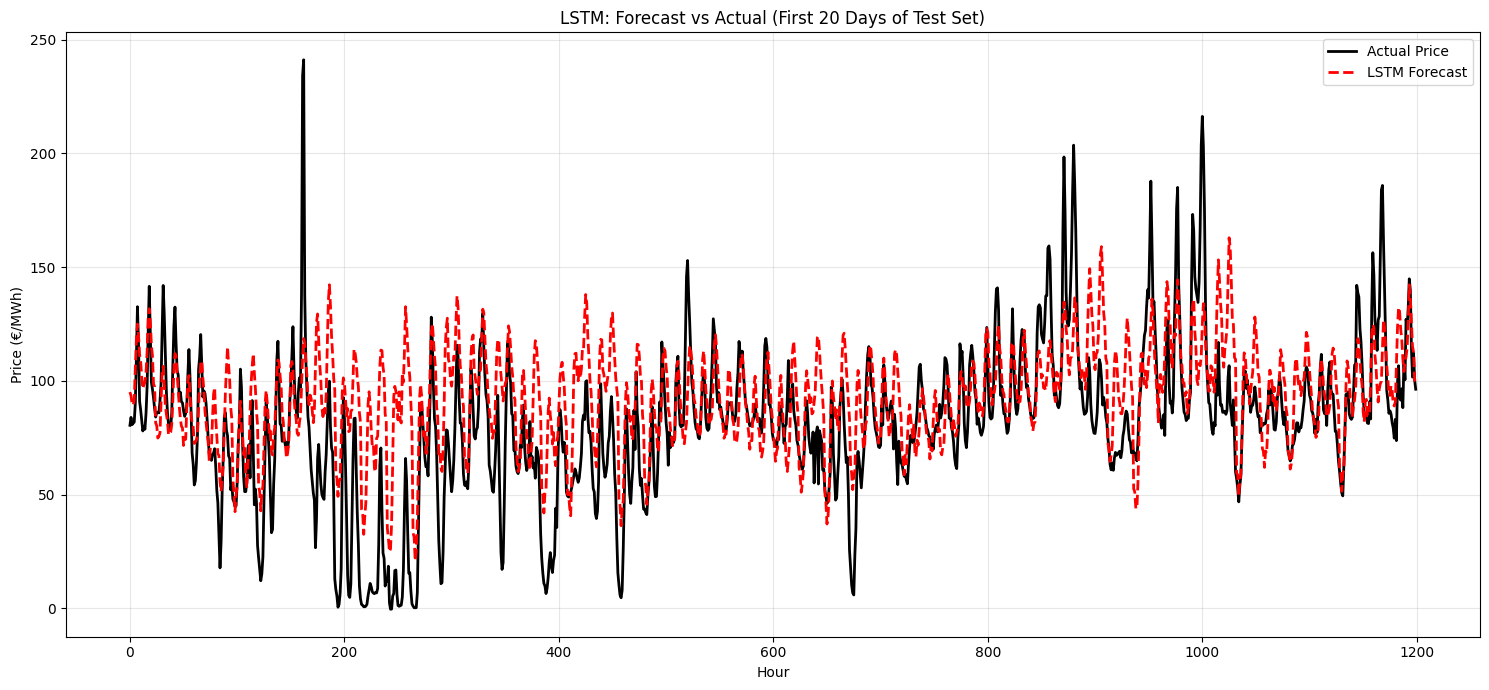

In [59]:
import matplotlib.pyplot as plt

n_plot_start = 150
n_plot = 200  # first 3 days

plt.figure(figsize=(15, 7))
plt.plot(actual_real[n_plot_start:n_plot].flatten(),
         label='Actual Price',
         color='black', linewidth=2)
plt.plot(pred_real[n_plot_start:n_plot].flatten(),
         label='LSTM Forecast',
         color='red', linestyle='--', linewidth=2)

plt.title('LSTM: Forecast vs Actual (First 20 Days of Test Set)')
plt.xlabel('Hour')
plt.ylabel('Price (€/MWh)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [34]:
#Save the model for future use
model_high.save('./trained_model/LSTM_2_high.keras')
model_low.save('./trained_model/LSTM_2_low.keras')
model_normal.save('./trained_model/LSTM_2_normal.keras')

# Save thresholds for future use
import pickle
thresholds = {
    'low_threshold':  low_threshold,
    'high_threshold': high_threshold
}
with open('./trained_model/LSTM_2_demand_thresholds.pkl', 'wb') as f:
    pickle.dump(thresholds, f)

with open('./trained_model/LTSM_2_scaler_x.pkl', 'wb') as f:
    pickle.dump(scaler_lstm_x, f)

with open('./trained_model/LTSM_2_scaler_y.pkl', 'wb') as f:
    pickle.dump(scaler_lstm_y, f)

print("All models and thresholds saved ✅")

All models and thresholds saved ✅


In [39]:
#Reload the model
from tensorflow.keras.models import load_model
import pickle

# ── Load all three models ──
model_high   = load_model('./trained_model/LSTM_2_high.keras')
model_low    = load_model('./trained_model/LSTM_2_low.keras')
model_normal = load_model('./trained_model/LSTM_2_normal.keras')

# ── Load thresholds ──
with open('./trained_model/LSTM_2_demand_thresholds.pkl', 'rb') as f:
    thresholds = pickle.load(f)

low_threshold  = thresholds['low_threshold']
high_threshold = thresholds['high_threshold']

with open('./trained_model/LTSM_2_scaler_x.pkl', 'rb') as f:
    scaler_lstm_x = pickle.load(f)

with open('./trained_model/LTSM_2_scaler_y.pkl', 'rb') as f:
    scaler_lstm_y = pickle.load(f)

print("Models loaded ✅")
print(f"Low threshold:  {low_threshold:.2f} €/MWh")
print(f"High threshold: {high_threshold:.2f} €/MWh")

Models loaded ✅
Low threshold:  75.15 €/MWh
High threshold: 143.47 €/MWh


          Model     MSE    MAE
0  Naive Weekly  361.35  13.77
1     7-Day Avg  395.15  16.73
2       Model 2  607.96  20.70


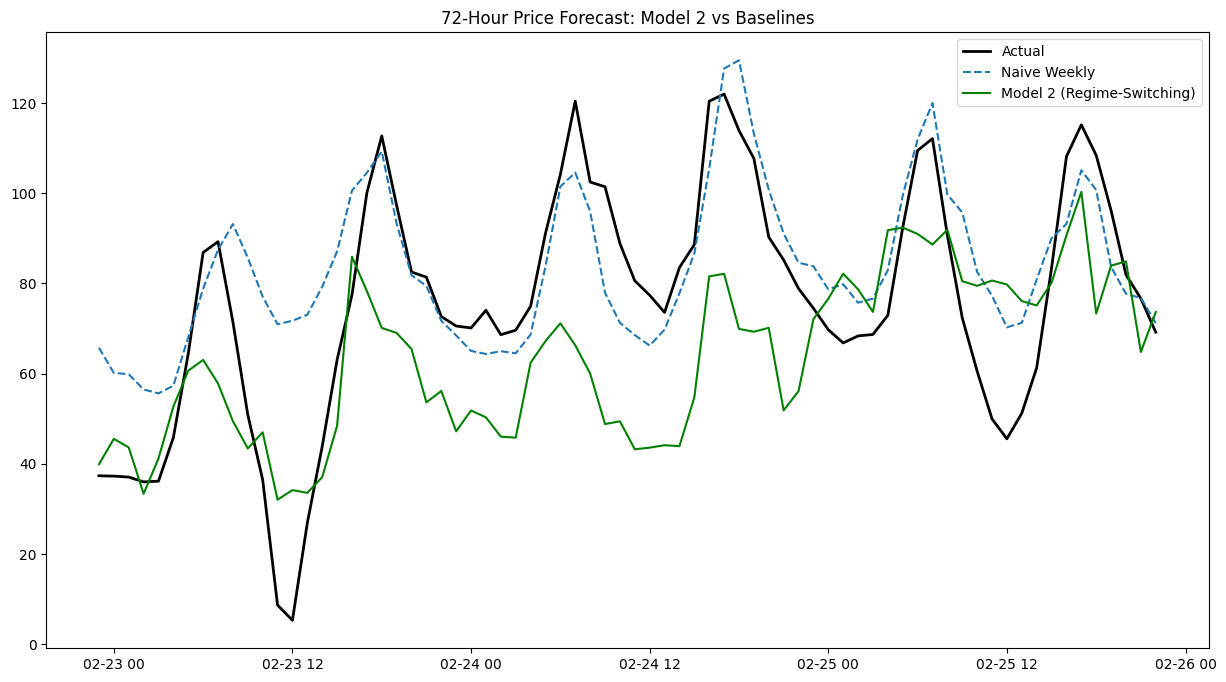

In [44]:
import pandas as pd
import numpy as np
import pickle
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# --- 1. Load and Prepare Data ---
df_hourly = pd.read_csv('Full_Dataset.csv')
df_hourly['Date'] = pd.to_datetime(df_hourly['Date'], dayfirst=True)
df_hourly = df_hourly.set_index('Date').sort_index()

# Extract actuals for the last 72 hours
test_actuals = df_hourly['Price_BE'].tail(72)
results_df = pd.DataFrame(index=test_actuals.index)
results_df['Actual'] = test_actuals.values

# --- 2. Calculate Baselines (Ensures 'Naive_Weekly' exists) ---
naive_weekly = []
avg_hourly_week = []

for timestamp in test_actuals.index:
    # Naive Weekly: Price exactly 7 days ago
    t_minus_7 = timestamp - pd.Timedelta(days=7)
    naive_weekly.append(df_hourly.loc[t_minus_7, 'Price_BE'] if t_minus_7 in df_hourly.index else np.nan)
    
    # 7-Day Hourly Average
    past_7_days_prices = []
    for d in range(1, 8):
        t_prev = timestamp - pd.Timedelta(days=d)
        if t_prev in df_hourly.index:
            past_7_days_prices.append(df_hourly.loc[t_prev, 'Price_BE'])
    avg_hourly_week.append(np.mean(past_7_days_prices) if past_7_days_prices else np.nan)

results_df['Naive_Weekly'] = naive_weekly
results_df['Avg_Hour_Last_Week'] = avg_hourly_week

# --- 3. Generate Predictions for Model 2 (Regime-Switching) ---
try:
    # A. Load Thresholds and ensure numeric types[cite: 1]
    with open('./trained_model/LSTM_2_demand_thresholds.pkl', 'rb') as f:
        thresh_data = pickle.load(f)
        if isinstance(thresh_data, dict):
            low_thresh = float(thresh_data.get('low', thresh_data.get('low_threshold')))
            high_thresh = float(thresh_data.get('high', thresh_data.get('high_threshold')))
        else:
            low_thresh, high_thresh = [float(x) for x in thresh_data]
    
    # B. Load Scalers
    with open('./trained_model/LTSM_2_scaler_x.pkl', 'rb') as f:
        scaler_x = pickle.load(f)
    with open('./trained_model/LTSM_2_scaler_y.pkl', 'rb') as f:
        scaler_y = pickle.load(f)

    # C. Load the sub-models[cite: 1]
    models = {
        'low': load_model('./trained_model/LSTM_2_low.keras'),
        'normal': load_model('./trained_model/LSTM_2_normal.keras'),
        'high': load_model('./trained_model/LSTM_2_high.keras')
    }

    # D. Prepare Scaled Data with training feature names to avoid UserWarning[cite: 1]
    feature_map = {'Price_BE': 'belpex', 'Solar_BE': 'solar', 'Wind_BE': 'wind', 'Load_BE': 'load'}
    df_for_scaling = df_hourly[['Price_BE', 'Solar_BE', 'Wind_BE', 'Load_BE']].rename(columns=feature_map)
    
    scaled_data = scaler_x.transform(df_for_scaling)
    df_scaled = pd.DataFrame(scaled_data, index=df_hourly.index, columns=df_for_scaling.columns)

    start_times = [test_actuals.index[0], test_actuals.index[24], test_actuals.index[48]]
    model_2_preds = []

    for start_time in start_times:
        input_start = start_time - pd.Timedelta(hours=168)
        input_end = start_time - pd.Timedelta(hours=1)
        
        input_data_raw = df_hourly.loc[input_start:input_end, 'Price_BE']
        input_seq_scaled = df_scaled.loc[input_start:input_end].values
        
        if len(input_seq_scaled) == 168:
            avg_price = float(input_data_raw.mean())
            
            # Select model based on thresholds[cite: 1]
            if avg_price < low_thresh:
                current_model = models['low']
            elif avg_price > high_thresh:
                current_model = models['high']
            else:
                current_model = models['normal']
            
            input_seq_scaled = input_seq_scaled.reshape(1, 168, 4)
            pred_scaled = current_model.predict(input_seq_scaled, verbose=0)
            model_2_preds.extend(scaler_y.inverse_transform(pred_scaled)[0])
        else:
            model_2_preds.extend([np.nan] * 24)

    results_df['Model_2_Predict'] = model_2_preds

except Exception as e:
    print(f"Error running Model 2 logic: {e}")
    results_df['Model_2_Predict'] = np.nan

# --- 4. Metrics and Plotting ---
def calculate_metrics(actual, predicted, model_name):
    mask = ~np.isnan(predicted) & ~np.isnan(actual)
    if not mask.any(): return {'Model': model_name, 'MSE': np.nan, 'MAE': np.nan}
    mse = mean_squared_error(actual[mask], predicted[mask])
    mae = mean_absolute_error(actual[mask], predicted[mask])
    return {'Model': model_name, 'MSE': round(mse, 2), 'MAE': round(mae, 2)}

# Display results
print(pd.DataFrame([
    calculate_metrics(results_df['Actual'], results_df['Naive_Weekly'], 'Naive Weekly'),
    calculate_metrics(results_df['Actual'], results_df['Avg_Hour_Last_Week'], '7-Day Avg'),
    calculate_metrics(results_df['Actual'], results_df['Model_2_Predict'], 'Model 2')
]))

plt.figure(figsize=(15, 8))
plt.plot(results_df.index, results_df['Actual'], label='Actual', color='black', linewidth=2)
plt.plot(results_df.index, results_df['Naive_Weekly'], label='Naive Weekly', linestyle='--')
plt.plot(results_df.index, results_df['Model_2_Predict'], label='Model 2 (Regime-Switching)', color='green')
plt.title('72-Hour Price Forecast: Model 2 vs Baselines')
plt.legend()
plt.show()